### Import Packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model
import statsmodels.api as sm
from scipy.optimize import minimize
from functools import *

### Import Dataset and Merge on Date

In [2]:
# Fill NaN and Inf values with the column mean
def fillbymean(x):
    """Fill NaN and Inf values with the column mean."""
    finite_vals = x[~x.isin([np.nan, np.inf, -np.inf])]  # Exclude NaN and Inf values
    mean_val = finite_vals.mean()
    return x.replace([np.nan, np.inf, -np.inf], mean_val)  # Replace invalid values with mean

# Z-score normalization (column-wise)
def zscore(df):
    """Apply Z-score normalization column-wise."""
    return (df - df.mean(axis=0)) / df.std(axis=0)

# Replace extreme values beyond N standard deviations with the median
def filter_by_median(df, N=1.96):
    """Replace values beyond N standard deviations from the median with the column median."""
    median_vals = df.median(axis=0)  # Compute column-wise median
    z_scores = (df - df.mean(axis=0)) / df.std(axis=0)  # Compute Z-scores column-wise

    # Replace extreme values with the median
    df_filtered = df.mask((z_scores < -N) | (z_scores > N), median_vals)
    
    return df_filtered

# Stock files and load function
stock_files = {
    'BAC': 'BAC.csv',
    'BLK': 'BLK.csv',
    'JPM': 'JPM.csv',
    'MET': 'MET.csv',
    'CME': 'CME.csv',
    'CG': 'CG.csv',
    'MS-PF': 'MS-PF.csv',
}

# Load and preprocess stock data
def load_stock_data(filename, ticker):
    df = pd.read_csv(filename, parse_dates=['Date'], dayfirst=True)
    df = df[(df['Date'] >= '2014-01-01') & (df['Date'] <= '2019-12-31')]
    if 'Adj Close' in df.columns:
        df = df[['Date', 'Adj Close']].rename(columns={'Adj Close': ticker})
    else:
        df = df[['Date', 'Adjusted Close']].rename(columns={'Adjusted Close': ticker})
    return df

# Merge all stock data, keeping Date as the index
dataset = None
for ticker, file in stock_files.items():
    stock_df = load_stock_data(file, ticker)
    if dataset is None:
        dataset = stock_df.set_index('Date')
    else:
        dataset = dataset.merge(stock_df.set_index('Date'), left_index=True, right_index=True, how='inner')

# Step 1: Fill NaN and Inf values for all columns
for col in dataset.columns:
    dataset[col] = fillbymean(dataset[col])  # Fill NaN and Inf values

# Step 2: Z-score normalization for each stock (column-wise)
dataset_normalized = dataset.copy()
for col in dataset_normalized.columns:
    dataset_normalized[col] = zscore(dataset_normalized[col])  # Apply Z-score normalization

# Step 3: Replace extreme values (Z-score > 1.96 or < -1.96) with the column median
dataset_filtered = dataset_normalized.copy()
for col in dataset_filtered.columns:
    dataset_filtered[col] = filter_by_median(dataset_filtered[col], 1.96)

# Check the result
print(dataset_filtered.head())

                 BAC       BLK       JPM       MET       CME        CG  \
Date                                                                     
2014-01-02 -0.951599 -1.269377 -1.134947 -0.514447 -1.151545  0.836726   
2014-01-03 -0.909073 -1.254507 -1.119853 -0.415127 -1.131132  0.975573   
2014-01-06 -0.874777 -1.255591 -1.108448 -0.451973 -1.144302  0.978527   
2014-01-07 -0.896727 -1.224225 -1.131257 -0.485614 -1.153850  0.972617   
2014-01-08 -0.885752 -1.225309 -1.112809 -0.354252 -1.166362  0.994773   

               MS-PF  
Date                  
2014-01-02  0.340259  
2014-01-03  0.340259  
2014-01-06  0.340259  
2014-01-07  0.340259  
2014-01-08  0.340259  


/var/folders/07/l8m36_9s2lz170jptjv7r6jc0000gn/T/ipykernel_27879/909555939.py:37: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df = pd.read_csv(filename, parse_dates=['Date'], dayfirst=True)


In [3]:
# Load Fama-French 3-Factor Data
ff_3f = pd.read_csv('ff3.csv', parse_dates=['Date'])
ff_3f = ff_3f[(ff_3f['Date'] >= '2014-01-01') & (ff_3f['Date'] <= '2019-12-31')].set_index('Date')

In [4]:
def normalize_and_replace(dataset):
    normalized_data = dataset.copy()  # Avoid modifying the original dataset

    for col in normalized_data.columns:
        mean = normalized_data[col].mean()
        std = normalized_data[col].std()
        median = normalized_data[col].median()

        # Compute Z-score
        z_scores = (normalized_data[col] - mean) / std

        # Replace extreme values with the mean
        normalized_data[col] = np.where((z_scores < -1.96) | (z_scores > 1.96), mean, normalized_data[col])

        # Recalculate the Z-score after replacing extreme values
        new_mean = normalized_data[col].mean()
        new_std = normalized_data[col].std()
        normalized_data[col] = (normalized_data[col] - new_mean) / new_std

    return normalized_data

# Apply normalization and replacement
dataset_normalized = normalize_and_replace(dataset)

# Display summary statistics after transformation
print(dataset_normalized.head())

                 BAC       BLK       JPM       MET       CME        CG  \
Date                                                                     
2014-01-02 -0.952000 -1.287846 -1.152666 -0.620415 -1.161906  1.071187   
2014-01-03 -0.908630 -1.272253 -1.136547 -0.509428 -1.140465  1.235743   
2014-01-06 -0.873653 -1.273390 -1.124369 -0.550602 -1.154298  1.239244   
2014-01-07 -0.896039 -1.240500 -1.148726 -0.588195 -1.164327  1.232240   
2014-01-08 -0.884846 -1.241637 -1.129025 -0.441401 -1.177469  1.258498   

              MS-PF  
Date                 
2014-01-02 -0.03971  
2014-01-03 -0.03971  
2014-01-06 -0.03971  
2014-01-07 -0.03971  
2014-01-08 -0.03971  


### Calculate individual stock returns, covariance, risk-free rate

In [ ]:
# dataset = dataset.fillna(method='ffill')
# returns = np.log(dataset / dataset.shift(1)).dropna()  # Index is now Date (datetime64[ns])
# mean_returns_annualized = returns.mean() * 252 
# print(mean_returns_annualized)

In [5]:
# Fill missing values using forward fill
dataset = dataset.fillna(method='ffill')
# Calculate daily returns as percentage change
returns = dataset.pct_change().dropna()  # pct_change calculates simple returns

# Calculate the mean of daily returns and annualize it by multiplying by 252
mean_returns_annualized = returns.mean() * 252

# Print the annualized mean returns
print(mean_returns_annualized)

BAC      0.177366
BLK      0.128355
JPM      0.193187
MET      0.073862
CME      0.217454
CG       0.109998
MS-PF    0.077165
dtype: float64


/var/folders/07/l8m36_9s2lz170jptjv7r6jc0000gn/T/ipykernel_27879/4040742903.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  dataset = dataset.fillna(method='ffill')


In [6]:
cov_matrix_annualized = returns.cov() * 252 
print(cov_matrix_annualized)

            BAC       BLK       JPM       MET       CME        CG     MS-PF
BAC    0.062659  0.036955  0.044723  0.045406  0.021843  0.031481  0.001762
BLK    0.036955  0.047130  0.031564  0.035165  0.018360  0.031669  0.001980
JPM    0.044723  0.031564  0.042030  0.037371  0.019457  0.027071  0.001409
MET    0.045406  0.035165  0.037371  0.058446  0.019990  0.029138  0.001720
CME    0.021843  0.018360  0.019457  0.019990  0.036690  0.011817 -0.000071
CG     0.031481  0.031669  0.027071  0.029138  0.011817  0.088817  0.003186
MS-PF  0.001762  0.001980  0.001409  0.001720 -0.000071  0.003186  0.004265


In [7]:
# Risk-free rate annualized, assuming 252 trading days
rf_rate = (1 + ff_3f['RF'].mean() / 100) ** 252 - 1
print(rf_rate)

0.00830341958753733


### Now, lets calculate the optimal portfolio weights
1. SLSQP minimizes a function of several variables with any combination of bounds, equality and inequality constraints. 
2. SLSQP is ideal for mathematical problems for which the objective function and the constraints are twice continuously differentiable. 
 <\br> https://docs.quantum.ibm.com/api/qiskit/0.41/qiskit.algorithms.optimizers.SLSQP

In [8]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize

# Assume returns and mean_returns_annualized, cov_matrix_annualized are already calculated

# Objective function to maximize the Sharpe ratio
def objective(weights, mean_returns, cov_matrix, risk_free_rate=0.0):
    # Portfolio Return
    portfolio_return = np.dot(weights, mean_returns)
    # Portfolio Volatility (Standard Deviation)
    portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    
    # Sharpe ratio (Risk-adjusted return)
    sharpe_ratio = (portfolio_return - risk_free_rate) / portfolio_volatility
    return -sharpe_ratio  # We negate it because we minimize in scipy.optimize

# Constraints and Bounds
def check_constraints(weights):
    # Ensure the sum of weights equals 1 (fully invested portfolio)
    return np.sum(weights) - 1

# Bounds for each stock weight (between 0 and 30% for each stock)
max_weight = 0.3 
bounds = [(0, max_weight) for _ in range(len(returns.columns))]

# Constraints dictionary for scipy.optimize
constraints = ({'type': 'eq', 'fun': check_constraints})

# Initial guess: Equal distribution among stocks
initial_guess = np.ones(len(returns.columns)) / len(returns.columns)

# Optimization to maximize the Sharpe ratio
result = minimize(objective, initial_guess, args=(mean_returns_annualized, cov_matrix_annualized),
                  method='SLSQP', bounds=bounds, constraints=constraints)

# Optimal weights based on Sharpe ratio maximization
optimal_weights = result.x

# Portfolio metrics
portfolio_return_annualized = np.dot(optimal_weights, mean_returns_annualized)
portfolio_volatility_annualized = np.sqrt(np.dot(optimal_weights.T, np.dot(cov_matrix_annualized, optimal_weights)))
portfolio_sharpe_ratio = (portfolio_return_annualized - 0) / portfolio_volatility_annualized  # Risk-free rate assumed to be 0

# Display the results
print("Optimal Portfolio Weights:", optimal_weights)
print("Portfolio Annualized Return:", portfolio_return_annualized)
print("Portfolio Annualized Volatility:", portfolio_volatility_annualized)
print("Portfolio Sharpe Ratio:", portfolio_sharpe_ratio)

Optimal Portfolio Weights: [0.00614025 0.05599205 0.3        0.         0.3        0.0378677
 0.3       ]
Portfolio Annualized Return: 0.15878325617714734
Portfolio Annualized Volatility: 0.12089243601886603
Portfolio Sharpe Ratio: 1.313425896657159


In [11]:
# Example of the objective function (assumes you already have it defined)
def objective(weights):
    portfolio_return = np.dot(weights, mean_returns_annualized)
    portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix_annualized, weights)))
    # Objective: maximize returns and minimize volatility (e.g., we want a risk-adjusted return)
    return -portfolio_return  # Negative because we are minimizing

# Loop over different portfolio weight ratios from 0.15 to 1.0 with interval 0.01
max_weight = 0.3
best_return = -np.inf  # Start with a very small number for best return
best_weights = None

# List to track returns for each ratio
returns_list = []

for ratio in np.arange(0.15, 1.01, 0.01):
    # Set the max weight for each ratio in the bounds
    bounds = [(0, ratio) for _ in range(len(returns.columns))]

    # Initial guess for weights: evenly distribute across assets
    initial_guess = np.ones(len(returns.columns)) / len(returns.columns)

    # Solve the optimization problem
    result = minimize(objective, initial_guess, method='SLSQP', bounds=bounds, constraints={'type': 'eq', 'fun': lambda weights: np.sum(weights) - 1})

    # Get the optimal weights from the result
    optimal_weights = result.x

    # Calculate the portfolio return and volatility
    portfolio_return_annualized = np.dot(optimal_weights, mean_returns_annualized)
    portfolio_volatility_annualized = np.sqrt(np.dot(optimal_weights.T, np.dot(cov_matrix_annualized, optimal_weights)))

    # Store the return and weight ratio
    returns_list.append((ratio, portfolio_return_annualized))

    # Update the best portfolio if we find a higher return
    if portfolio_return_annualized > best_return:
        best_return = portfolio_return_annualized
        best_weights = optimal_weights

# Print the best portfolio ratio and its return
print("Best portfolio ratio:", best_weights)
print("Largest annualized return:", best_return)

# Optionally, you can print all portfolio returns for each weight ratio
for ratio, return_ in returns_list:
    print(f"Ratio: {ratio:.2f}, Annualized Return: {return_:.4f}")

Best portfolio ratio: [0.00000000e+00 0.00000000e+00 0.00000000e+00 2.17995592e-17
 1.00000000e+00 0.00000000e+00 0.00000000e+00]
Largest annualized return: 0.2174540715427249
Ratio: 0.15, Annualized Return: 0.1429
Ratio: 0.16, Annualized Return: 0.1475
Ratio: 0.17, Annualized Return: 0.1521
Ratio: 0.18, Annualized Return: 0.1565
Ratio: 0.19, Annualized Return: 0.1609
Ratio: 0.20, Annualized Return: 0.1653
Ratio: 0.21, Annualized Return: 0.1680
Ratio: 0.22, Annualized Return: 0.1708
Ratio: 0.23, Annualized Return: 0.1736
Ratio: 0.24, Annualized Return: 0.1763
Ratio: 0.25, Annualized Return: 0.1791
Ratio: 0.26, Annualized Return: 0.1811
Ratio: 0.27, Annualized Return: 0.1831
Ratio: 0.28, Annualized Return: 0.1852
Ratio: 0.29, Annualized Return: 0.1872
Ratio: 0.30, Annualized Return: 0.1892
Ratio: 0.31, Annualized Return: 0.1913
Ratio: 0.32, Annualized Return: 0.1933
Ratio: 0.33, Annualized Return: 0.1953
Ratio: 0.34, Annualized Return: 0.1964
Ratio: 0.35, Annualized Return: 0.1969
Ratio

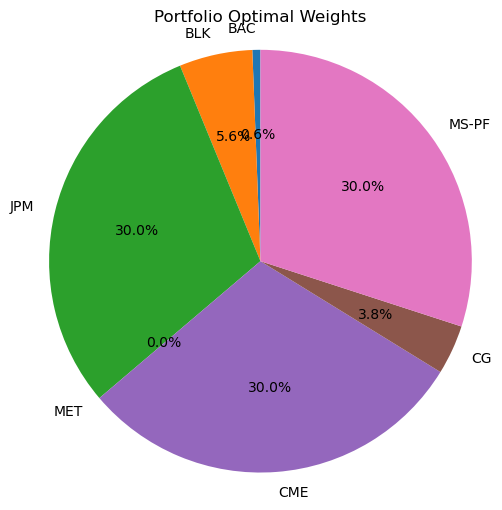

In [23]:
# Pie Chart of Optimal Weights
plt.figure(figsize=(6, 6))
plt.pie(optimal_weights, labels=returns.columns, autopct='%1.1f%%', startangle=90)
plt.title("Portfolio Optimal Weights")
plt.axis('equal')
plt.show()

### Regression: Testing the FF3 model

In [20]:
# Calculate daily portfolio returns
portfolio_returns_daily = returns.dot(optimal_weights)
portfolio_returns_daily = pd.DataFrame(portfolio_returns_daily, columns=['Portfolio_Return'], index=returns.index)

# Merge with Fama-French data (both have Date as datetime index)
data_for_regression = portfolio_returns_daily.merge(ff_3f, left_index=True, right_index=True, how='inner')

# Calculate daily portfolio excess returns
data_for_regression['Portfolio_Excess_Return'] = data_for_regression['Portfolio_Return'] - data_for_regression['RF']

# Define dependent and independent variables
y = data_for_regression['Portfolio_Excess_Return']
X = data_for_regression[['SMB', 'HML']] # Exclude RF from X since it's already subtracted
X = sm.add_constant(X)

# Run the regression
model = sm.OLS(y, X)
results = model.fit()
print(results.summary())

                               OLS Regression Results                              
Dep. Variable:     Portfolio_Excess_Return   R-squared:                       0.049
Model:                                 OLS   Adj. R-squared:                  0.048
Method:                      Least Squares   F-statistic:                     39.02
Date:                     Mon, 17 Mar 2025   Prob (F-statistic):           3.00e-17
Time:                             23:07:43   Log-Likelihood:                 5000.8
No. Observations:                     1509   AIC:                            -9996.
Df Residuals:                         1506   BIC:                            -9980.
Df Model:                                2                                         
Covariance Type:                 nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
co

### Now, what if we use an equally weighted portfolio?

In [21]:
# Portfolio expected return and volatility (annualized)
portfolio_return_annualized2 = np.dot(initial_guess, mean_returns_annualized)                                     # Annualized expected return
portfolio_volatility_annualized2 = np.sqrt(np.dot(initial_guess.T, np.dot(cov_matrix_annualized, initial_guess))) # Annualized volatility

print(f"\nPortfolio Expected Return (Annualized): {portfolio_return_annualized2:.4f}")
print(f"Portfolio Volatility (Annualized): {portfolio_volatility_annualized2:.4f}")


Portfolio Expected Return (Annualized): 0.1396
Portfolio Volatility (Annualized): 0.1593


### Some visualizations

/var/folders/07/l8m36_9s2lz170jptjv7r6jc0000gn/T/ipykernel_86204/3440097792.py:3: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  annualized_returns = cumulative_returns.resample('Y').last()  # Take the last value of each year


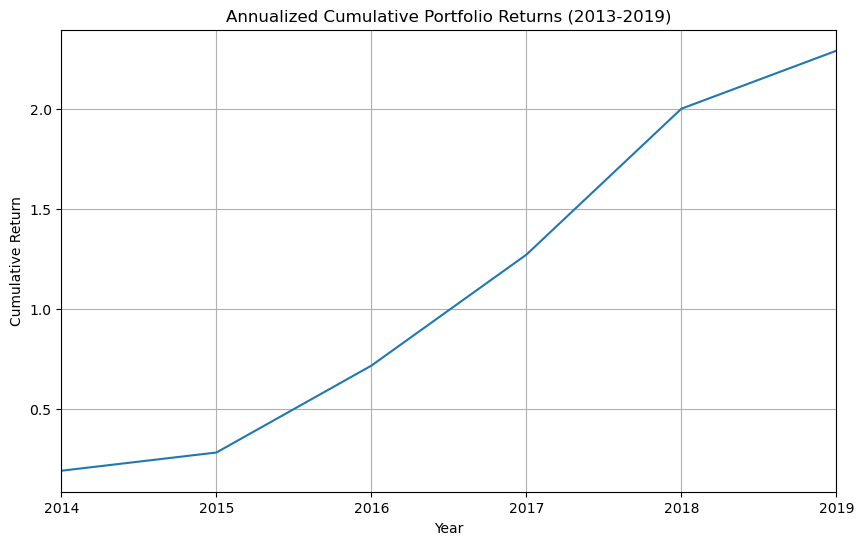

In [15]:
# Visualization 1: Annualized cumulative returns
cumulative_returns = (1 + portfolio_returns_daily['Portfolio_Return']).cumprod() - 1
annualized_returns = cumulative_returns.resample('Y').last()  # Take the last value of each year

# Plot annualized cumulative returns
plt.figure(figsize=(10, 6))
annualized_returns.plot()
plt.title("Annualized Cumulative Portfolio Returns (2013-2019)")
plt.xlabel("Year")
plt.ylabel("Cumulative Return")
plt.grid(True)
plt.show()

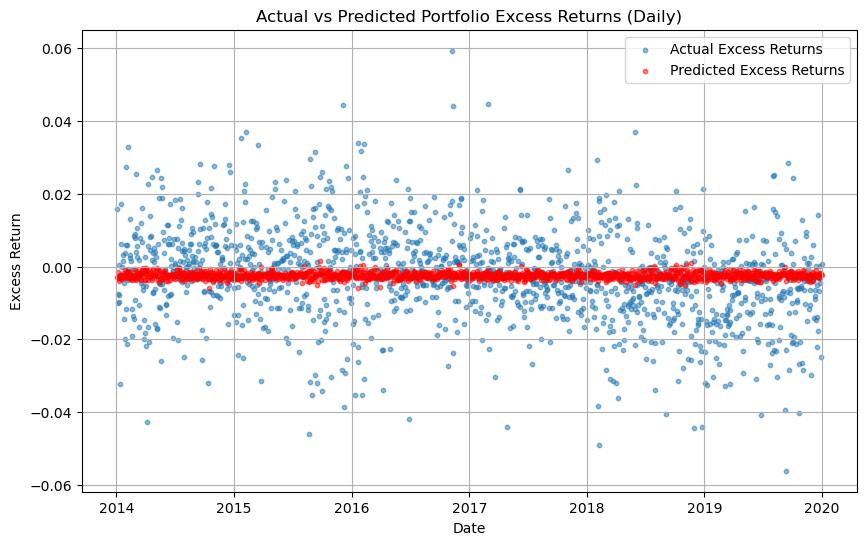

In [16]:
predicted_excess_returns = results.fittedvalues
plt.figure(figsize=(10, 6))
plt.scatter(data_for_regression.index, y, label="Actual Excess Returns", alpha=0.5, s=10)
plt.scatter(data_for_regression.index, predicted_excess_returns, color='red', label="Predicted Excess Returns", alpha=0.5, s=10)
plt.title("Actual vs Predicted Portfolio Excess Returns (Daily)")
plt.xlabel("Date")
plt.ylabel("Excess Return")
plt.legend()
plt.grid(True)
plt.show()